# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [1]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 1 threads 😎


In [2]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [3]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [4]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [5]:
import Pkg

# Activa el entorno del proyecto
Pkg.activate("../../../")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `~/Escritorio/Projects/Pushing/ABM_CBM`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Project.toml`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA /home/julia/.julia/packages/CUDA/jdJ7Z/lib/cudadrv/version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [6]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
            :eta=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [7]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=6* 1.E5 *m/(t^2*d) #Pa
com.eta=150 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [8]:
com.N

30

In [9]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [10]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [11]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

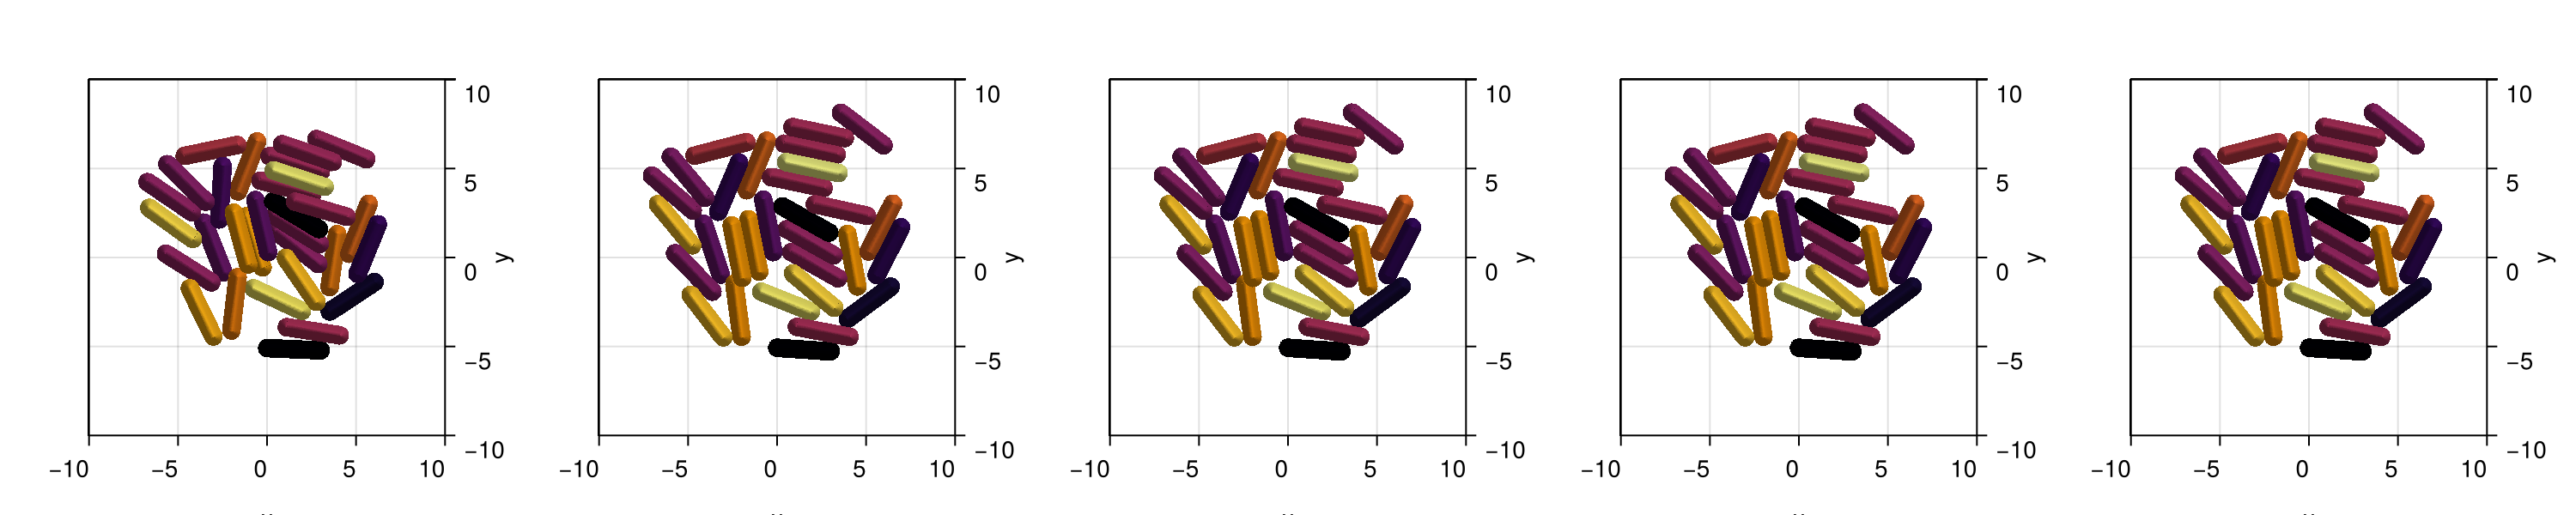

CairoMakie.Screen{IMAGE}


In [12]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [13]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "Tods_c.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "Tods_c.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [14]:
function plotMixedAgents2D!(ax, x, y, d, l, angle, type, p; kargs...)
    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)


        if ti== 0  # rods
            # colorval = pi
            # colormap = :Blues
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],

                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:blue],

                kargs...
            )
        else  # puntos
            colorval = pi
            colormap = :Reds
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:red],
                colormap = colormap,
                kargs...
            )
        end

    end
    return
end


plotMixedAgents2D! (generic function with 1 method)

In [15]:
rods2dGrowth = ABM(2,
    baseModelInit = [rod2D],

    agent = Dict(
                :dg=> Float64, 
                :lTarget => Float64,
                :type => Int,
                :growth=>Float64,
                :Kc => Float64, #Half saturation constant for the medium
                :generation => Int,
                :v => Float64, 
                :r => Float64, #Distance to the origin
            ),

    model = Dict(
                :σlTarget=>Float64,
                :lMax=>Float64,
                :D_c => Float64,
                :cm => Float64, #Medium concentration
                :beta_c => Float64, #Growth rate of the cells in the medium
                :alpha_c => Float64,  #Decay rate of the cells in the medium
                :D_PGA=>Float64, #Diffusion coefficient for the medium
                :delta_PGA=>Float64, #Decay rate of the medium
                :alpha_PGA=>Float64, #Decay rate of the cells in the medium
                :Kch => Float64, #Half saturation constant for the medium
                :nh => Int, #Hill coefficient for the medium
                :rmax => Float64, #Maximum growth rate of the cells in the medium
                :gamma_c => Float64, #Decay rate of the cells in the medium
                :gamma_d => Float64, #Decay rate of the cells in the medium
                :a_c => Float64, #Decay rate of the cells in the medium
                :a_d => Float64, #Decay rate of the cells in the medium
            ),
    
    medium = Dict(
        :D_eff => Float64, #Distance to the origin
        :alpha_eff => Float64, #Decay rate of the cells in the medium
        :c => Float64,        #Add a medium parameter
        :PGA => Float64,        #Add a medium parameter
        :Hx => Float64,  #Add a medium parameter
        :Hy => Float64        #Add a medium parameter
    ),

 
    agentODE = quote    
        dt(l) = l*growth*c/(Kc+c) #linear growth with growth dependent on the pressure over the cell

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij

            fx-= v * Hx
            fy-= v * Hy
            
            

            
        end
        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*1.E-2 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    dg=dg,
                    generation = generation + 1)
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww,
                    dg=dg,
                    generation = generation + 1)
            #Remove the old cell
            @removeAgent()
        end
        
        c += (-l*beta_c*c/(Kc+c))*dt
        if type !=0
            PGA += (alpha_PGA*c^nh/(Kch^nh+c^nh))*dt
        end
        r = sqrt(x ^ 2 + y ^ 2) #Distance to the origin
        if r> rmax
            rmax=r
        end
        
  
    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    mediumODE=quote 

        if @mediumInside()
            dt(c) =D_eff*(@∂2(1,c)+@∂2(2,c)) - alpha_eff*(c - cm)
            dt(PGA) = D_PGA*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA
            Hx = @∂(1,PGA) 
            Hy = @∂(2,PGA)
        elseif @mediumBorder(1,-1)
            c = cm
            PGA = 0
        elseif @mediumBorder(1,1)
            c = cm
            PGA = 0

        elseif @mediumBorder(2,-1)
            c = cm
            PGA = 0

        elseif @mediumBorder(2,1)
            c = cm
            PGA = 0

        end

    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

## Grow colony from one cell

In [16]:
com = Community(rods2dGrowth,
            N=100,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[100,100],
            );

#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta=200 *m/(t^2*d) #Pa h

com.PGA=0
com.alpha_PGA = 10
com.delta_PGA = 1
com.D_PGA = 20
com.v =1
 

com.growth = 5
com.lMax = 4.     
com.σlTarget = 1. 
com.generation = 0 
 
com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  

com.D_c = 1
com.cm = 1 #Medium concentration
com.Kc = 0.3 #Half saturation constant for the medium
com.beta_c = 0.01 #Growth rate of the cells in the medium
com.alpha_c = 0.3  #Decay rate of the cells in the medium
com.Kch = 0.2 #Half saturation constant for the medium
com.nh = 2 #Hill coefficient for the medium

com.rmax = 0.0 #Maximum growth rate of the cells in the medium
com.gamma_c = 0.1 #Decay rate of the cells in the medium
com.gamma_d = 0.1 #Decay rate of the cells in the medium
com.a_c = 0.0001 #Decay rate of the cells in the medium
com.a_d = 0.0001 #Decay rate of the cells in the medium

com.c=1
com.x = 0
com.y = 0
com.theta = 0;

In [17]:
com.NMedium[1]/2

50.0

In [18]:
com.rmax

1-element Vector{Float64}:
 0.0

In [19]:
steps=Int(round(1/com.dt))
# saveEach=steps/100
saveEach=Int(round(10/com.dt))/100
# steps=100000
# saveEach=10000
N=com.N*3 

loadToPlatform!(com,preallocateAgents=N)
open("Tods_c.txt", "w") do f
    # clear file at start
end

for step in 1:steps
    
    step!(com)
    com.c=1
    


    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end

bringFromPlatform!(com)


Step 1000 N: 200
Step 2000 N: 219
Step 3000 N: 375
Step 4000 N: 400
Step 5000 N: 560
Step 6000 N: 800
Step 7000 N: 854
Step 8000 N: 1415
Step 9000 N: 1600


CompositeException: TaskFailedException

    nested task error: InterruptException:
    Stacktrace:
      [1] cos(x::Float64)
        @ Base.Math ./special/trig.jl:98
      [2] point2line(x1::Float64, y1::Float64, x2::Float64, y2::Float64, theta2::Float64)
        @ CellBasedModels.CBMMetrics ~/Escritorio/Projects/Pushing/ABM_CBM/src/metrics.jl:170
      [3] rodIntersection(x1::Float64, y1::Float64, l1::Float64, theta1::Float64, x2::Float64, y2::Float64, l2::Float64, theta2::Float64; separation::Float64)
        @ CellBasedModels.CBMMetrics ~/Escritorio/Projects/Pushing/ABM_CBM/src/metrics.jl:225
      [4] rodIntersection
        @ ~/Escritorio/Projects/Pushing/ABM_CBM/src/metrics.jl:202 [inlined]
      [5] repulsiveForces_rods(x::Float64, y::Float64, d::Float64, l::Float64, theta::Float64, x2::Float64, y2::Float64, d2::Float64, l2::Float64, theta2::Float64, eta::Float64, E::Float64)
        @ CellBasedModels.CBMModels ~/Escritorio/Projects/Pushing/ABM_CBM/src/models/bac_pga.jl:84
    

In [20]:
prev_steps = 0
steps=Int(round(0.5/com.dt))
com.growth = 0
open("Tods_c.txt", "w") do f
    # clear file at start
end

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)


    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)

Step 1000 N: 1621
Step 2000 N: 1621
Step 3000 N: 1621
Step 4000 N: 1621
Step 5000 N: 1621


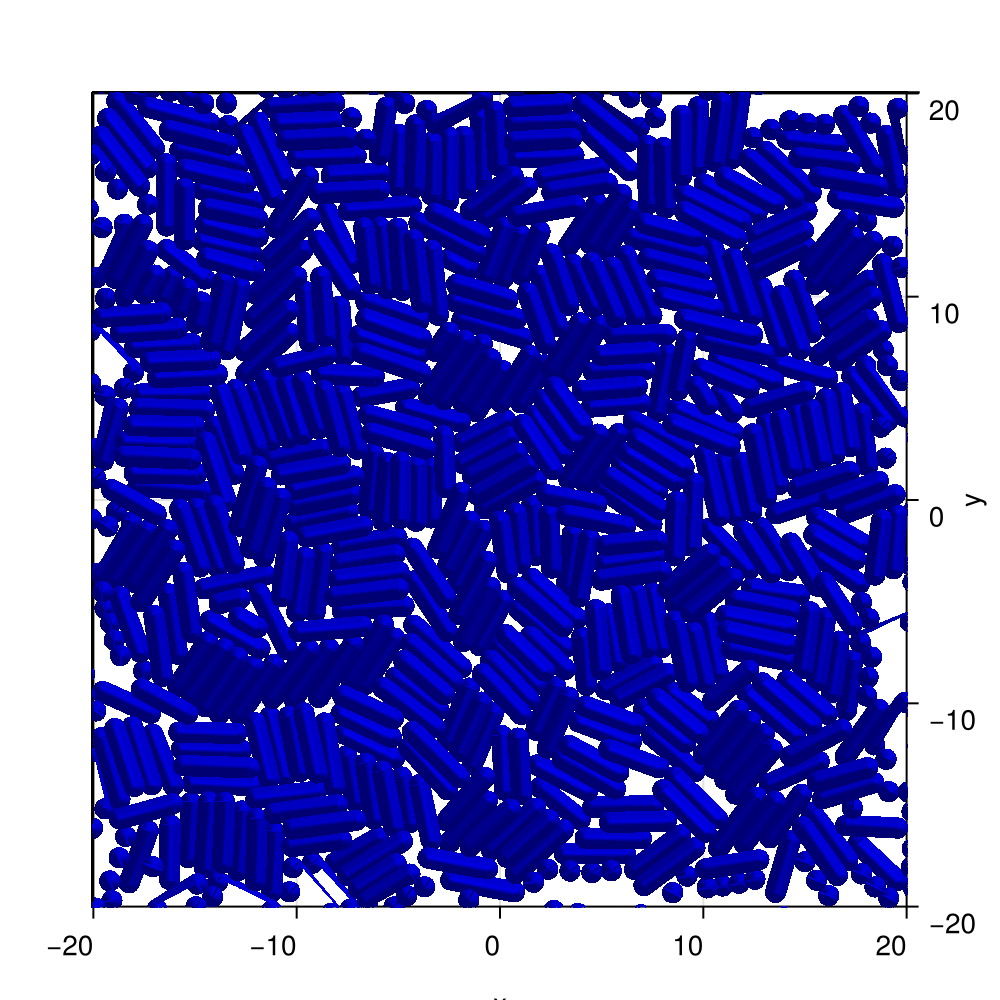

CairoMakie.Screen{IMAGE}


In [21]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(500,500))

js = length(com_load)
# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate([js])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

display(fig)

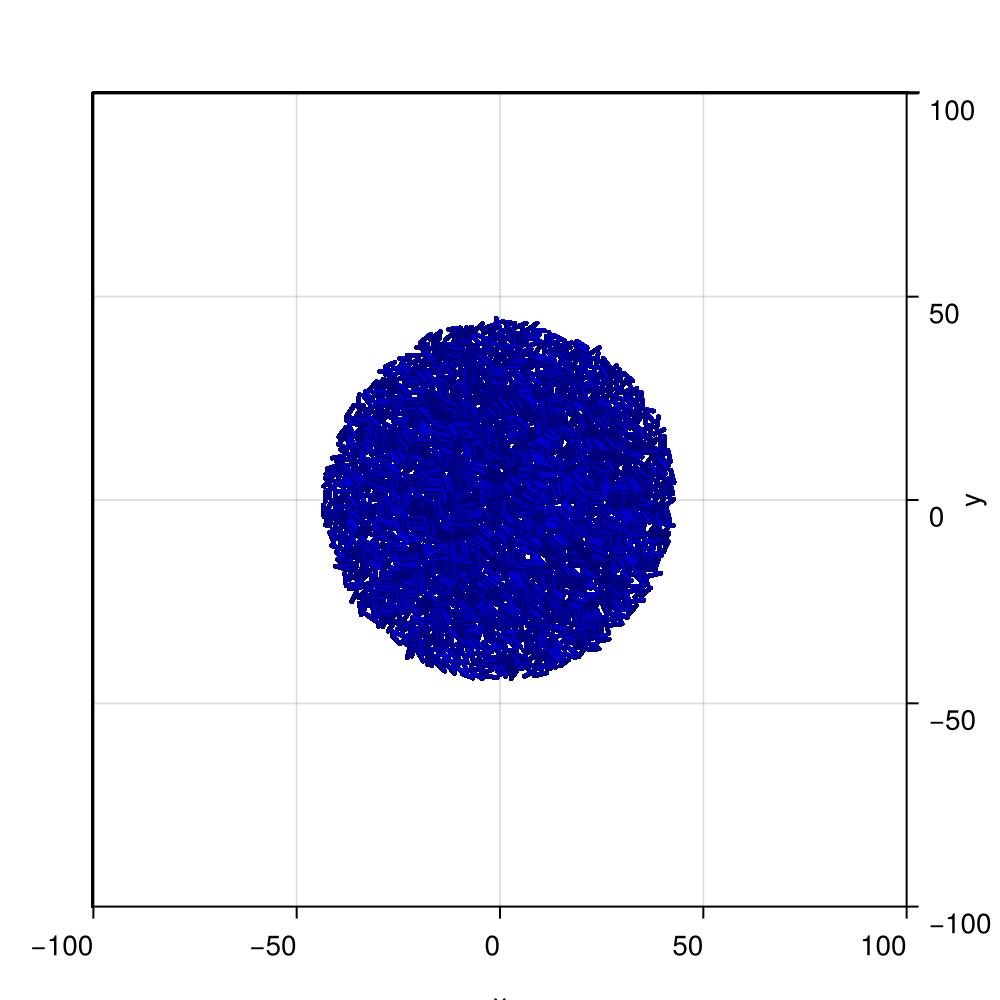

CairoMakie.Screen{IMAGE}


In [22]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(500,500))

js = length(com_load)
# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate([js])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

display(fig)

In [24]:
com.rmax

1-element Vector{Float64}:
 43.934474516515095

In [26]:
# for i in 1:Int(com.NMedium[1])
#     for j in 1:Int(com.NMedium[2])
#         aux=(exp(-com.gamma_d[1]*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2))+com.a_d[1])/(1+com.a_d[1])
#         com.D_eff[i,j]=com.D_c[1] *aux
#         aux=(exp(-com.gamma_c[1]*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2))+com.a_c[1])/(1+com.a_c[1])
#         com.alpha_eff[i,j]=com.alpha_c[1]*aux
#     end

# end
# log_community_state(com.parameters, steps)

In [25]:
com.D_c=50
com.alpha_c=25
for i in 1:Int(com.NMedium[1])
    for j in 1:Int(com.NMedium[2])
        com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)+10
        com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)+0.1
    
    end

end
log_community_state(com.parameters, steps)

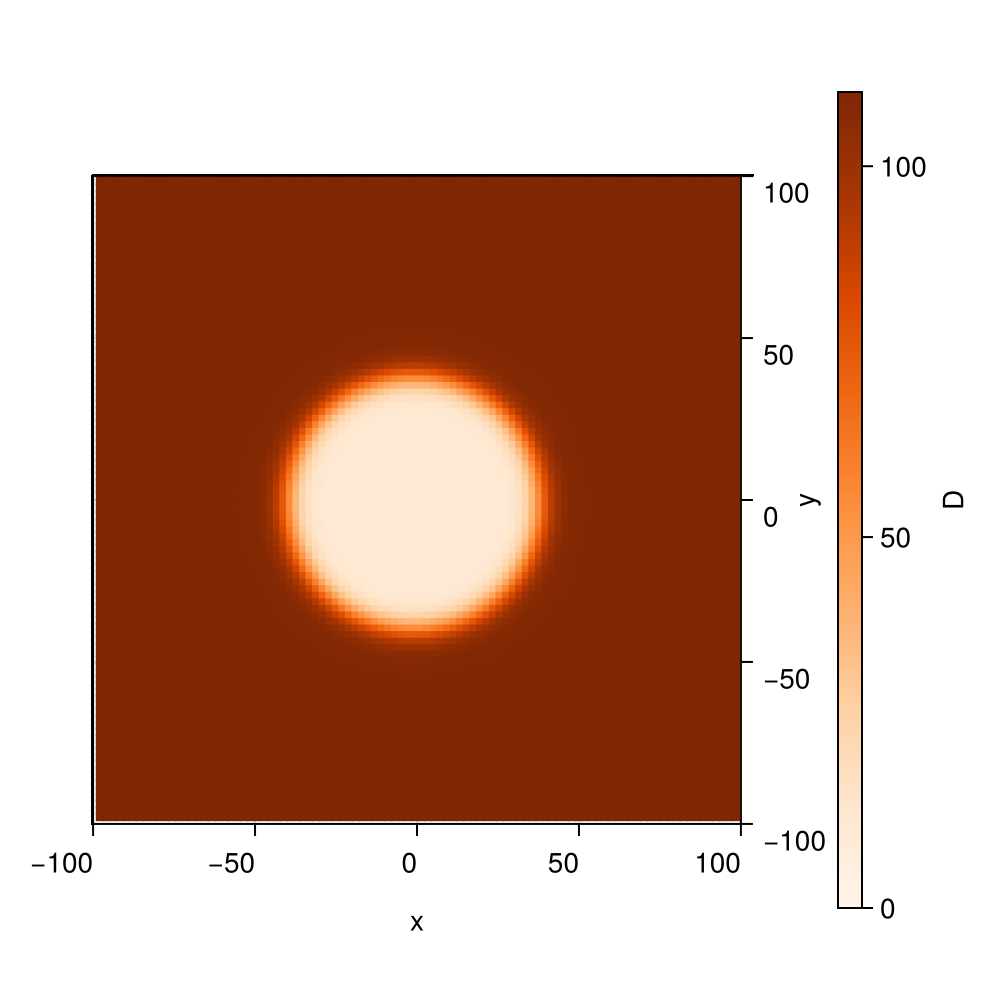

CairoMakie.Screen{IMAGE}


In [28]:
# Colormap común y colorrange fijo
# colormap = :viridis
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:D_eff]), com_load)))
# colorrange_c = (0.0, com.D_c[1])


fig = Figure(size=(500,500))

js = length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:D_eff]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "D"
)

display(fig)



In [26]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:alpha_eff]), com_load)))
# colorrange_c = (0.0,  1)


fig = Figure(size=(500,500))

js = [length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:alpha_eff]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "flow"
)

display(fig)



ErrorException: Invalid text boundingbox GeometryBasics.HyperRectangle{3, Float64}([109.0, NaN, 0.0], [7.783999919891357, 16.309999465942383, 0.0])

In [27]:
prev_steps = 0
steps=Int(round(1/com.dt))
com.c = 0
com.growth = 0.2
com.beta_c = 0.01
com.Kc =0.5
com.D_c=50
com.alpha_c=25
open("Tods_c.txt", "w") do f
    # clear file at start
end
for i in 1:Int(com.NMedium[1])
    for j in 1:Int(com.NMedium[2])
        com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)+10
        com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)+0.1
    
    end

end
loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)

    for i in 1:Int(com.NMedium[1])
        for j in 1:Int(com.NMedium[2])
            com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)
            com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)
        
        end

    end

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)

Step 1000 N: 1621
Step 2000 N: 1622
Step 3000 N: 1624
Step 4000 N: 1625
Step 5000 N: 1625
Step 6000 N: 1628
Step 7000 N: 1629
Step 8000 N: 1632
Step 9000 N: 1634
Step 10000 N: 1640


In [29]:
bringFromPlatform!(com)

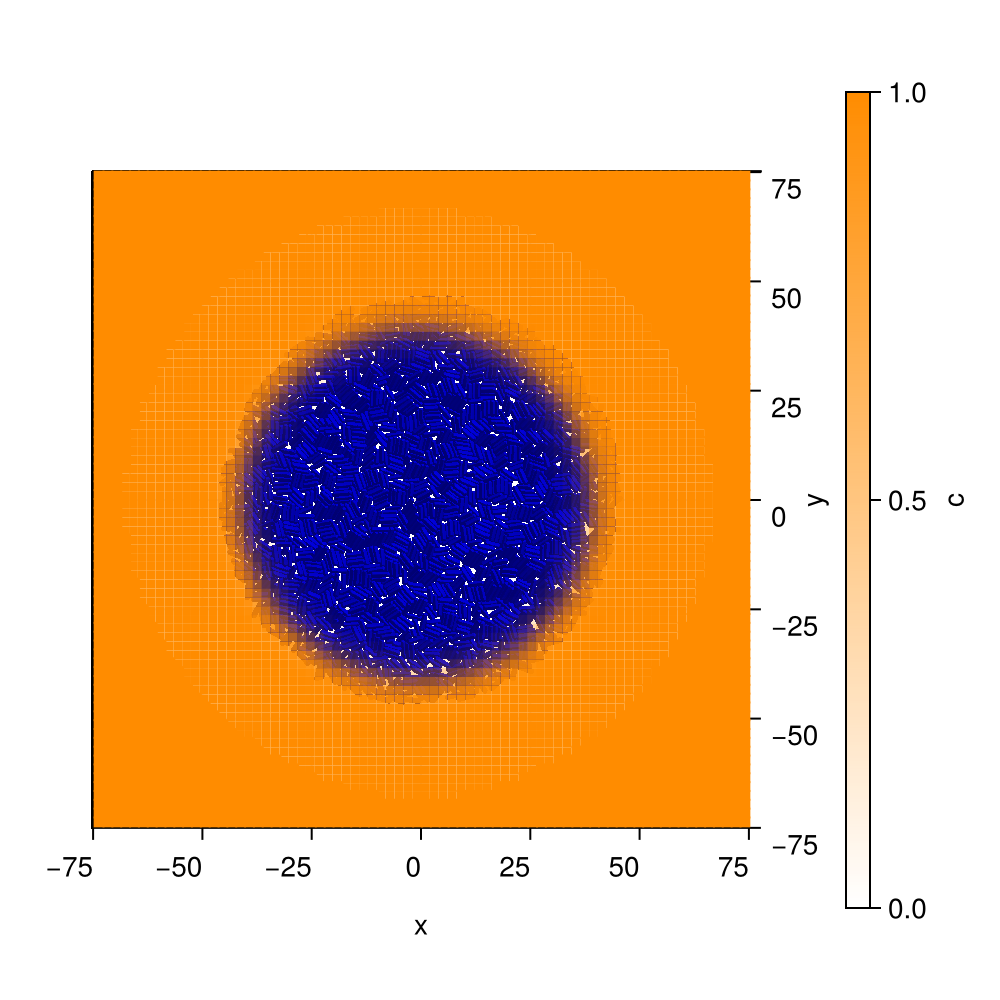

CairoMakie.Screen{IMAGE}


In [30]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-75,75)
    ylims!(-75,75)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

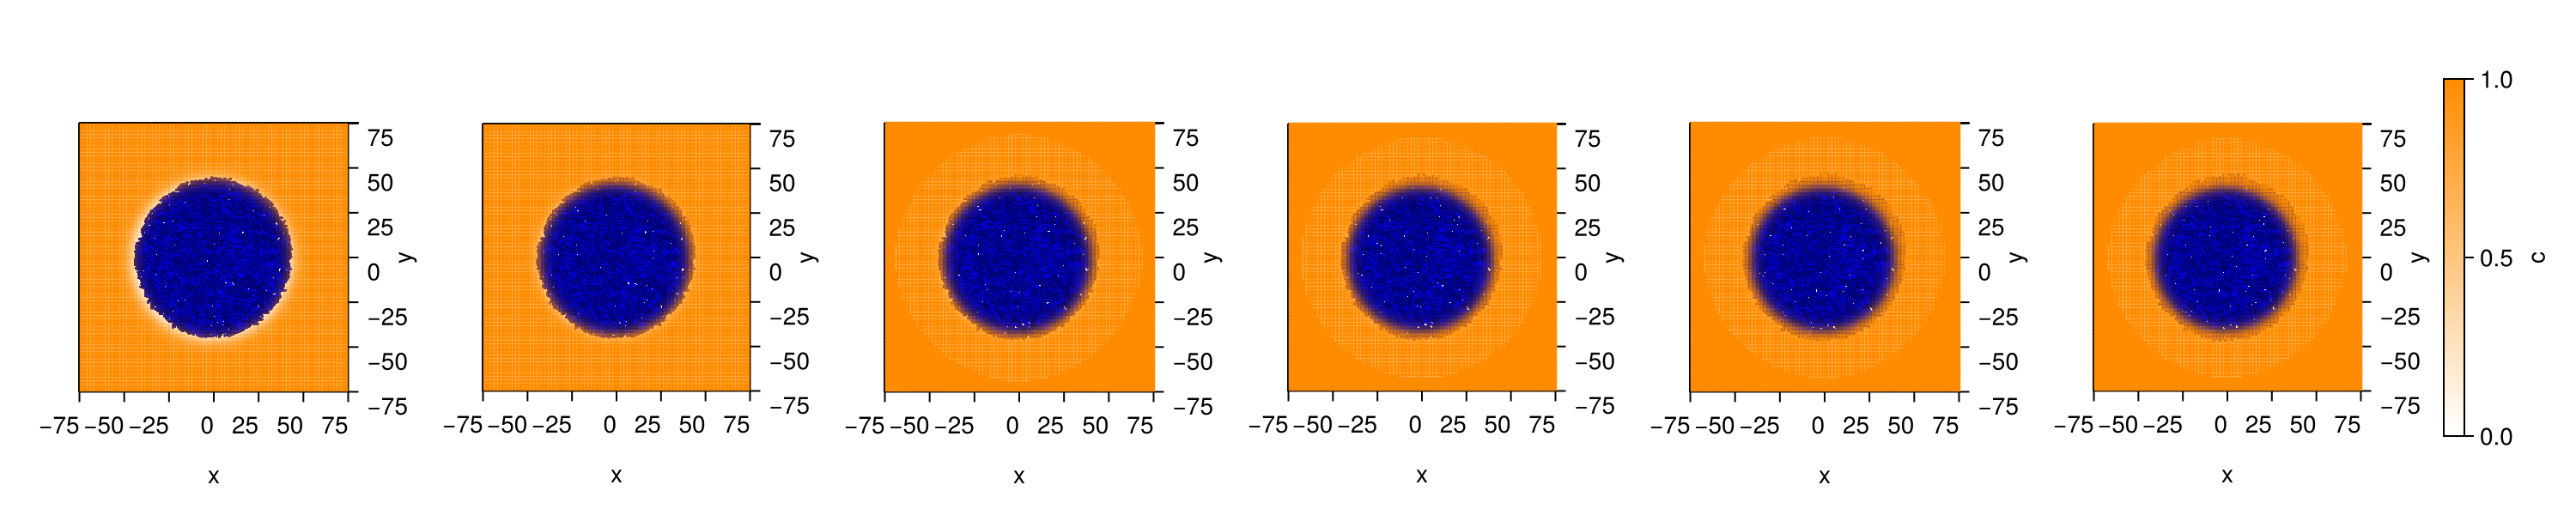

CairoMakie.Screen{IMAGE}


In [31]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
# colorrange_c = (0.0,  0.5)

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-75,75)
    ylims!(-75,75)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

In [32]:
com.c[50, 50], com.c[50, 25] ,  com.c[50, 30] 


(2.0092515306297636e-5, 0.9984623397897668, 0.5656441027854238)

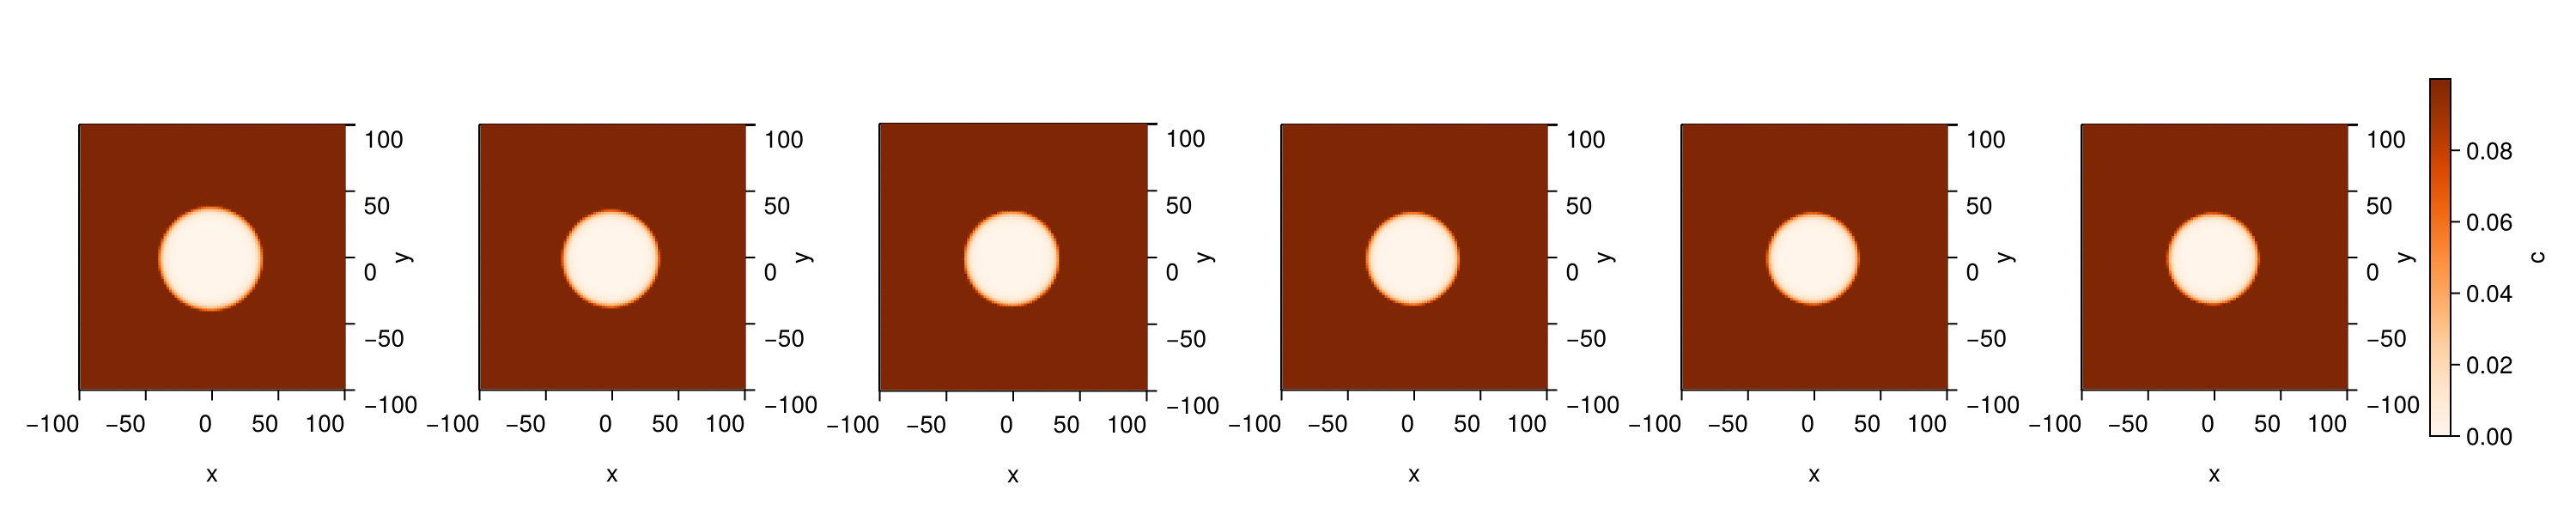

CairoMakie.Screen{IMAGE}


In [33]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  0.1)


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [34]:
maximum(maximum(p -> maximum(p[:PGA]), com_load))

0.0

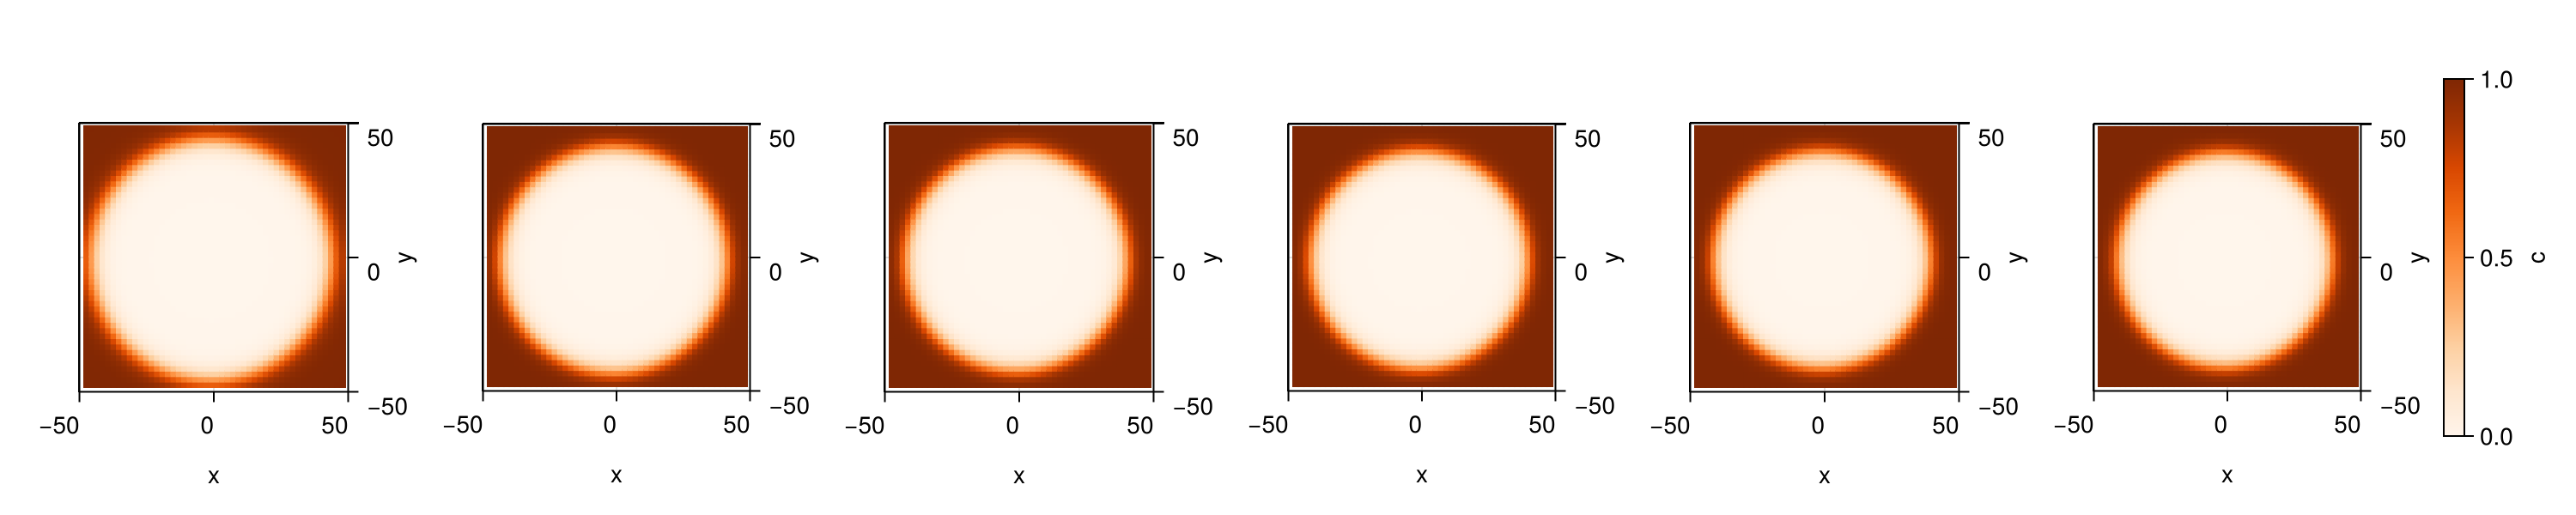

CairoMakie.Screen{IMAGE}


In [35]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [ ]:
# bringFromPlatform!(com)

# idmax=findfirst(x -> x == maximum(com.x), com.x)
# com.type[idmax] = 1 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == maximum(com.y), com.y)
# com.type[idmax] = 2 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == minimum(com.x), com.x)
# com.type[idmax] = 3 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == minimum(com.y), com.y)
# com.type[idmax] = 4 #Change the type of the first cell to 1, so it can be identified as the first cell
# println(sum(com.type .!= 0))
# log_community_state(com.parameters, steps)
# com_load,times=load_parameters_log("Tods_c.txt")


In [41]:
# cx, cy = 0, 15
# R2 = 100  # comparamos con el cuadrado del radio para evitar sqrt
# com.growth = 0.2
com.type =0
rmax = 0
for i in range(1,length(com.x))
    r = com.x[i]^2 + com.y[i]^2
    if r > rmax
        rmax = r
    end
    theta = atan(com.y[i], com.x[i])
    R =  1000*exp(-50*theta^(2))+ 200
    prob = R^6/(R^6+r^6)
    if prob > rand()
        com.type[i] = 1
    else
        com.type[i] = 0
    end
end

println(sum(com.type .== 1))
log_community_state(com.parameters, steps)
com_load,times=load_parameters_log("Tods_c.txt")




220


(OrderedDict{Symbol, Any}[OrderedDict(:a_c => Any[0.0001], :Kc => Any[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5  …  0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], :c => Any[Any[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], Any[1.0, 0.9992010986195365, 0.9985519902162203, 0.9981189910107223, 0.9978780379352572, 0.9977642393739043, 0.9977178768680951, 0.9977013452175432, 0.9976961206639687, 0.9976946413270738  …  0.9976946382977637, 0.997696110344911, 0.9977013140339743, 0.9977177945233223, 0.997764053063638, 0.9978776863573259, 0.9981184596370248, 0.9985513919213461, 0.9992006837600431, 1.0], Any[1.0, 0.9985519902162203, 0.9973755047457779, 0.9965907393906778, 0.9961540600103989, 0.9959478355959179, 0.995863823841488, 0.9958338697059532, 0.9958244039491336, 0.9958217239330058  …  0.995821718445435, 0.9958243852546331, 0.9958338132075849, 0.9958636746373275, 0.9959474979864651, 0.9961534228779171, 0.9965897763714834, 0.

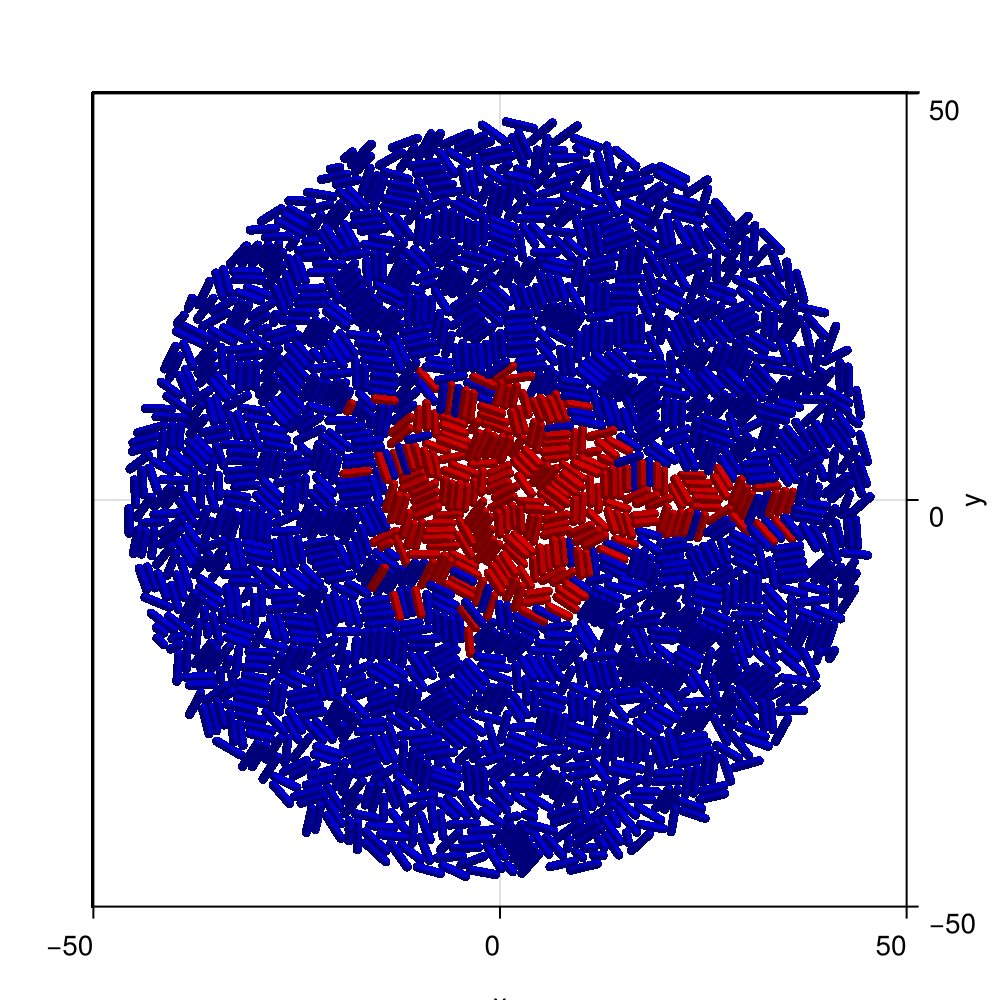

CairoMakie.Screen{IMAGE}


In [42]:
fig = Figure(size=(500,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

In [43]:
com_load,times=load_parameters_log("Tods_c.txt")

(OrderedDict{Symbol, Any}[OrderedDict(:a_c => Any[0.0001], :Kc => Any[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5  …  0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], :c => Any[Any[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], Any[1.0, 0.9992010986195365, 0.9985519902162203, 0.9981189910107223, 0.9978780379352572, 0.9977642393739043, 0.9977178768680951, 0.9977013452175432, 0.9976961206639687, 0.9976946413270738  …  0.9976946382977637, 0.997696110344911, 0.9977013140339743, 0.9977177945233223, 0.997764053063638, 0.9978776863573259, 0.9981184596370248, 0.9985513919213461, 0.9992006837600431, 1.0], Any[1.0, 0.9985519902162203, 0.9973755047457779, 0.9965907393906778, 0.9961540600103989, 0.9959478355959179, 0.995863823841488, 0.9958338697059532, 0.9958244039491336, 0.9958217239330058  …  0.995821718445435, 0.9958243852546331, 0.9958338132075849, 0.9958636746373275, 0.9959474979864651, 0.9961534228779171, 0.9965897763714834, 0.

In [44]:
for i in 1:Int(com.NMedium[1])
    for j in 1:Int(com.NMedium[2])
        aux=(exp(-com.gamma_d[1]*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2))+com.a_d[1])/(1+com.a_d[1])
        com.D_eff[i,j]=com.D_c[1] *aux
        aux=(exp(-com.gamma_c[1]*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2))+com.a_c[1])/(1+com.a_c[1])
        com.alpha_eff[i,j]=com.alpha_c[1]*aux
    end

end

In [45]:
com.x[1:length(com_load[end][:x])] = com_load[end][:x]
com.y[1:length(com_load[end][:y])] = com_load[end][:y]
com.l[1:length(com_load[end][:l])] = com_load[end][:l]
com.d[1:length(com_load[end][:d])] = com_load[end][:d]
com.theta[1:length(com_load[end][:theta])] = com_load[end][:theta]

vecs = [Float64.(v) for v in com_load[end][:c]]
c_load = hcat(vecs...)
com.c=c_load
com.PGA=0

0

In [46]:

bringFromPlatform!(com)

com.PGA=0
com.alpha_PGA = 10
com.delta_PGA = 0
com.D_PGA = 10
com.Kch = 0.001 
com.v = 0.5

log_community_state(com.parameters, 0, "Motiles.txt")

In [ ]:
prev_steps=0
steps=Int(round(3/com.dt))

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)
    for i in 1:Int(com.NMedium[1])
        for j in 1:Int(com.NMedium[2])
            com.D_eff[i,j]=com.D_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)
            com.alpha_eff[i,j]=com.alpha_c[1]*(tanh(-0.2*(com.rmax[1]-sqrt((i-com.NMedium[1]/2)^2+(j-com.NMedium[2]/2)^2)*2+5))+1)
        
        end

    end

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step, "Motiles.txt")
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 31000 N: 1782
Step 32000 N: 1797
Step 33000 N: 1812
Step 34000 N: 1824
Step 35000 N: 1834
Step 36000 N: 1850
Step 37000 N: 1867
Step 38000 N: 1880
Step 39000 N: 1898
Step 40000 N: 1913


CompositeException: TaskFailedException

    nested task error: InterruptException:
    Stacktrace:
      [1] pointInsideRod(x1::Float64, y1::Float64, l1::Float64, theta1::Float64, pxAux::Float64, pyAux::Float64, separation::Float64)
        @ CellBasedModels.CBMMetrics ~/Escritorio/Projects/Pushing/ABM_CBM/src/metrics.jl:184
      [2] rodIntersection(x1::Float64, y1::Float64, l1::Float64, theta1::Float64, x2::Float64, y2::Float64, l2::Float64, theta2::Float64; separation::Float64)
        @ CellBasedModels.CBMMetrics ~/Escritorio/Projects/Pushing/ABM_CBM/src/metrics.jl:234
      [3] rodIntersection
        @ ~/Escritorio/Projects/Pushing/ABM_CBM/src/metrics.jl:202 [inlined]
      [4] repulsiveForces_rods(x::Float64, y::Float64, d::Float64, l::Float64, theta::Float64, x2::Float64, y2::Float64, d2::Float64, l2::Float64, theta2::Float64, eta::Float64, E::Float64)
        @ CellBasedModels.CBMModels ~/Escritorio/Projects/Pushing/ABM_CBM/src/models/bac_pga.jl:84
      [5] macro expansion
 

In [52]:
saveEach

1000.0

In [55]:
com_load,times=load_parameters_log("Motiles.txt")


(OrderedDict{Symbol, Any}[OrderedDict(:a_c => Any[0.0001], :Kc => Any[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5  …  0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], :c => Any[Any[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], Any[1.0, 0.9999999999999938, 0.9999999999999923, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992  …  0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.999999999999992, 0.9999999999999923, 0.9999999999999938, 1.0], Any[1.0, 0.9999999999999923, 0.9999999999999905, 0.9999999999999899, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898  …  0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999898, 0.9999999999999899, 0.9999999999

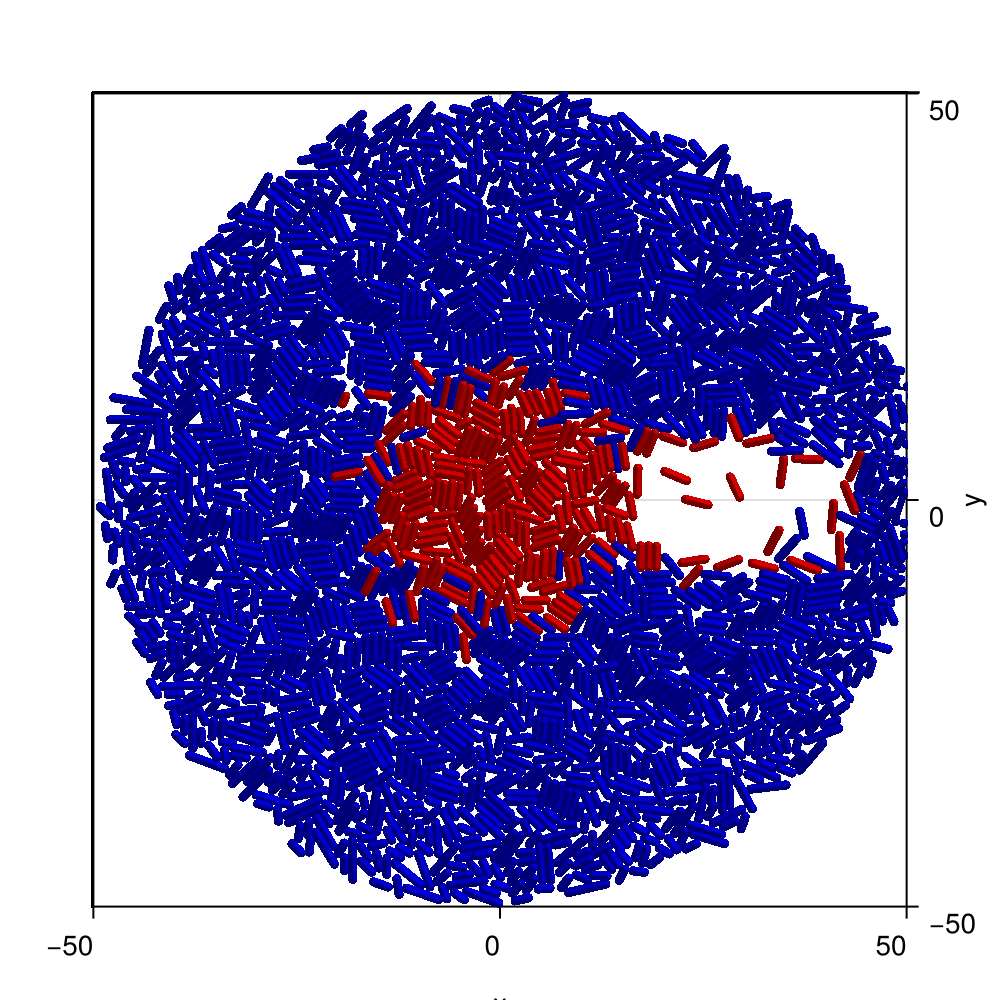

CairoMakie.Screen{IMAGE}


In [56]:
fig = Figure(size=(500,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

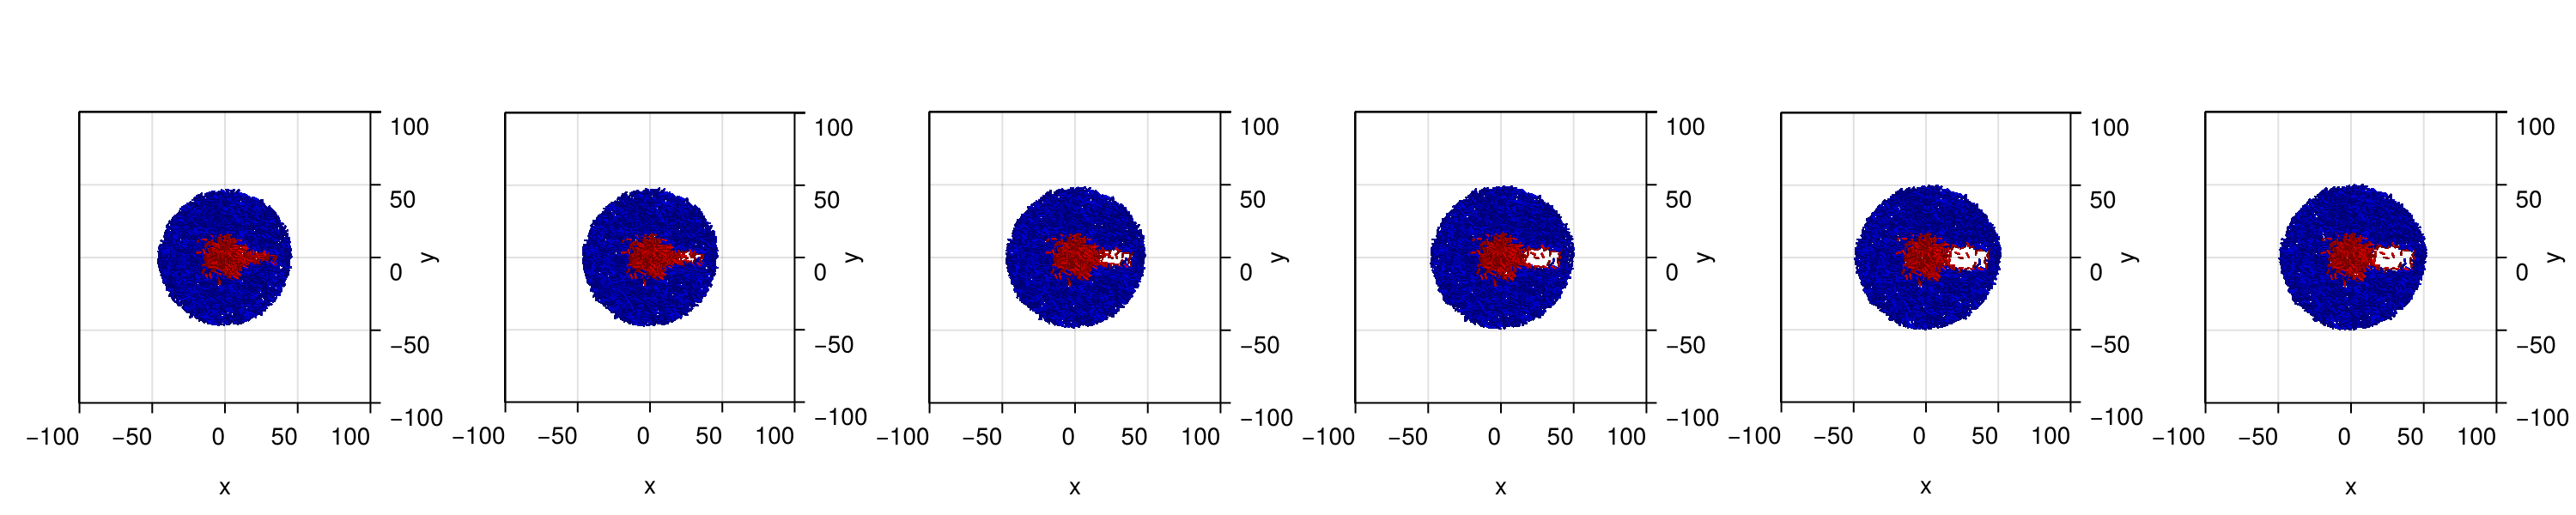

CairoMakie.Screen{IMAGE}


In [65]:
fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

display(fig)

In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)

display(fig)



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    



    xlims!(-80,80)
    ylims!(-80,80)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [ ]:
cmap_transp_green = cgrad(
    [RGBAf(0, 1, 0.3, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0, 1, 0.3, 1.0)],  # verde con alfa 1 (opaco)
    256
)
cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=cmap_transp_green
# colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m1 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    m2 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )



    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)

display(fig)



In [68]:
function plotMixedAgents!(ax, x, y, d, l, angle, type, p; kargs...)
    # Diccionario de tipos a colormaps (puedes extenderlo con más tipos y colores)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)
        # Colormap según tipo, o uno genérico si no está definido
        colormap = get(colormap_dict, ti, :viridis)

        # Color numérico según p
        colorval = pi

        # Esferas en los extremos
        for dx in (-1, 1)
            meshscatter!(ax,
                [xi + dx * li/2 * cos(ai)],
                [yi + dx * li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = colorval,
                colormap = colormap,
                kargs...
            )
        end

        # Cuerpo alargado
        meshscatter!(ax,
            [xi],
            [yi];
            marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
            markersize = [Point3f(li, di/2, di/2)],
            rotation = [ai],
            color = colorval,
            colormap = colormap,
            kargs...
        )
    end
    return
end


plotMixedAgents! (generic function with 1 method)

In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.c)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    

    plotMixedAgents!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:generation],
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "QS"
# )

display(fig)

In [45]:
function plot_evolution_by_type_from_positions(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure()
    ax = Axis(fig[1, 1], 
            xlabel = "θ",
            ylabel = "r",
            yreversed = true,
            )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)

            # Ángulo relativo calculado por desplazamiento
            angles = atan.(ys, xs)  



            colormap = haskey(colormap_dict, ti) ? colormap_dict[ti] : error("Tipo $ti no tiene colormap definido")

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    # axislegend(ax)
    return fig
end


plot_evolution_by_type_from_positions (generic function with 1 method)

In [72]:
function plot_evolution(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure(backgroundcolor = :black)  # Fondo negro

    ax = Axis(
        fig[1, 1],
        xlabel = "θ",  # Letra griega
        ylabel = "r",
        yreversed = true,
        backgroundcolor = :black,
        xlabelcolor = :white,
        ylabelcolor = :white,
        xticklabelcolor = :white,
        yticklabelcolor = :white,
        xtickcolor = :white,
        ytickcolor = :white,
        bottomspinecolor = :white,
        leftspinecolor = :white,
        rightspinecolor = :white,
        topspinecolor = :white
    )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)
            angles = atan.(ys, xs)

            colormap = get(colormap_dict, ti, :viridis)

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    return fig
end


plot_evolution (generic function with 1 method)

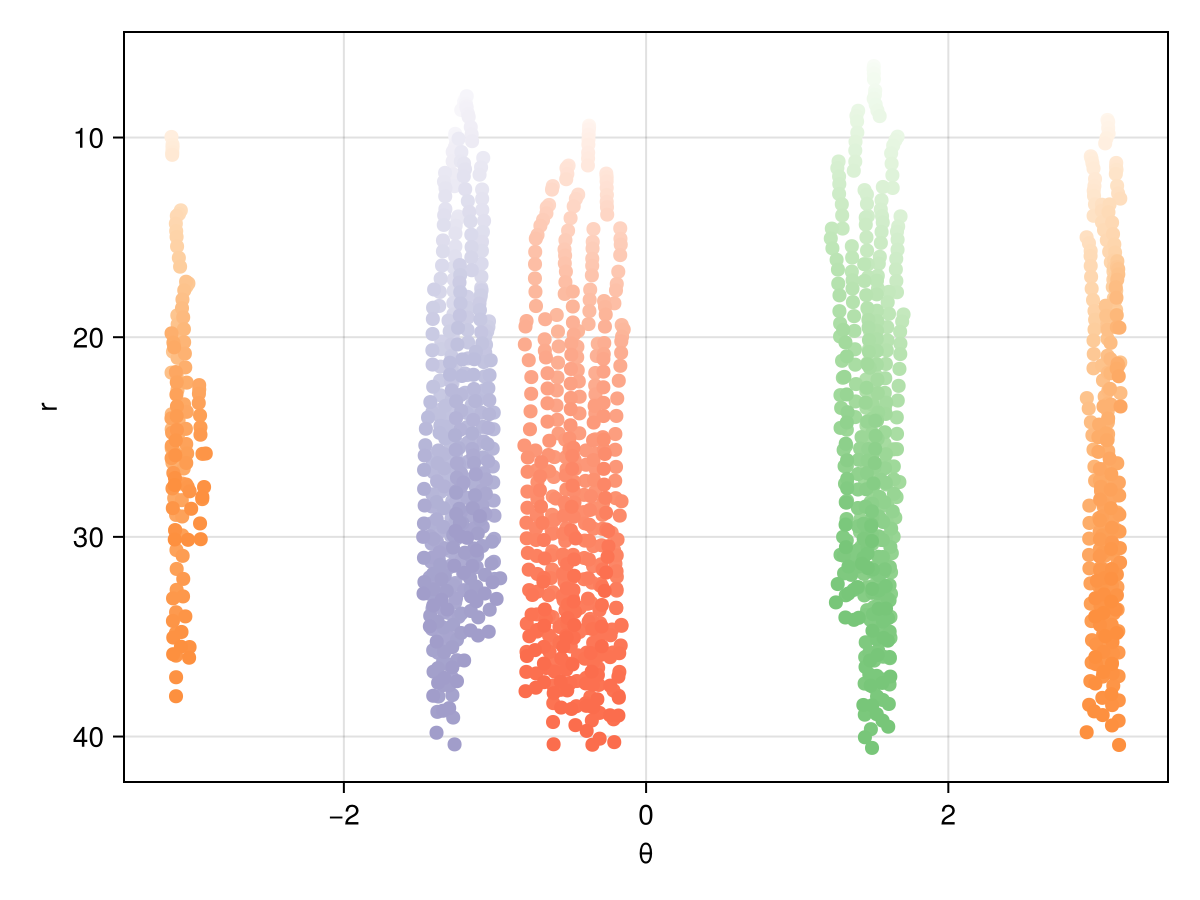

In [28]:
plot_evolution_by_type_from_positions(com_load)

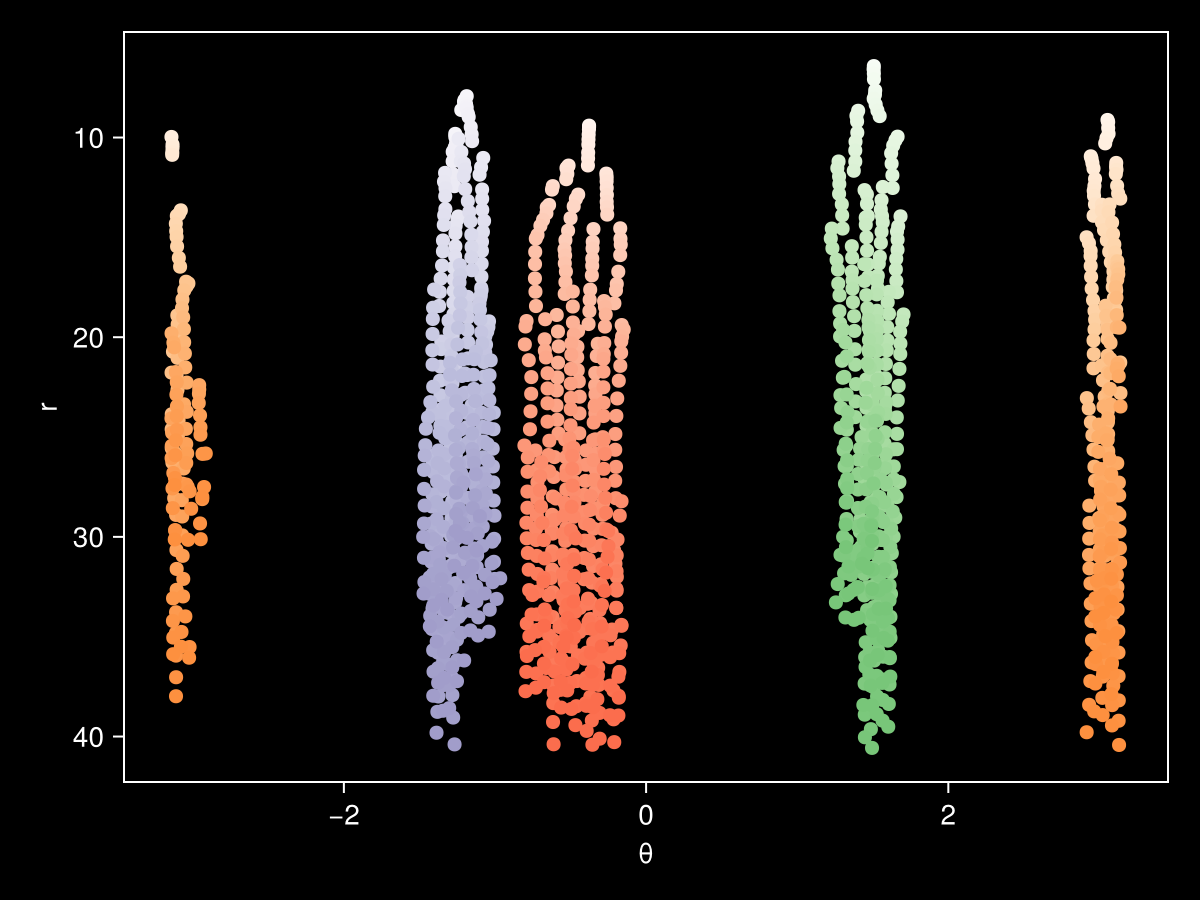

In [31]:
plot_evolution(com_load)


In [69]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())


# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)

Makie.record(fig, "Tods.mp4", 1:1:Int(length(com_load)); framerate = 5) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:d],
        colorrange = colorrange
    )


    xlims!(ax, -85, 85)
    ylims!(ax, -85, 85)
end


"Tods.mp4"

In [ ]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())

cmap_transp_green = cgrad(
    [RGBAf(0, 1, 0.3, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0, 1, 0.3, 1.0)],  # verde con alfa 1 (opaco)
    256
)
cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    256
)

simBox_cpu = Array(com.simBox)  # copia a CPU
colormap_PGA=cmap_transp_green
# colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)
Colorbar(fig[1, 2],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)
Colorbar(fig[1, 3],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

Makie.record(fig, "Tods_fields.mp4", 1:1:Int(length(com_load)); framerate = 5) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:d],
        colorrange = colorrange
    )
    m1 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    m2 = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )


    xlims!(ax, -85, 85)
    ylims!(ax, -85, 85)
end
